# U5_08 — Sistema Multi-Agente: Predicción de Toxicidad de Nanopartículas

**Proyecto Final | Unidad 5 — Sistemas Multi-Agente Modernos**  
**Tema:** Predicción de Toxicidad de Nanopartículas mediante Machine Learning  
**Dificultad:** Avanzada ★★★★★  
**Entorno:** `ia_nano` (Python 3.11)

---

## Arquitectura del Sistema (9 Agentes + Coordinador)

```
USUARIO
   ↓
┌─────────────────────────────────────────────────────┐
│  AGENTE 1: COORDINADOR (LangGraph StateGraph)       │
│  • Recibe solicitud del usuario                     │
│  • Decide qué agentes activar                       │
│  • Gestiona flujo de información                    │
│  • Monitorea el proceso (LangSmith)                 │
└─────────────────────────────────────────────────────┘
   ↓         ↓         ↓        ↓        ↓       ↓       ↓       ↓
 [2]Ingesta [3]Limpieza [4]Features [5]Train [6]Eval [7]SHAP [8]Pred [9]Viz

Infraestructura transversal:
  - Neo4j       → Memoria de grafo (nanopartículas, modelos, relaciones)
  - LangSmith   → Observabilidad y trazas de cada agente
  - ChromaDB    → Memoria semántica (papers de nanotoxicidad)
  - OpenRouter  → LLM para agentes de texto (gratis)
```

## Flujo de Datos
```
Datos crudos → Datos limpios → Features → Modelo → Evaluación → Interpretación → Predicción → Reporte
```


## Sección 1 — Instalación y Warm-Up

Verifica e instala los paquetes necesarios, luego carga las claves API desde `.env`.

In [1]:
# ============================================================
# CELDA 1 — DIAGNÓSTICO Y CORRECCIÓN DE ENTORNO ia_nano
# ============================================================
import subprocess, sys

print('=' * 55)
print('  DIAGNÓSTICO DEL ENTORNO ia_nano')
print('=' * 55)

# 1. Verificar y reparar matplotlib
print('\n[1/3] Verificando matplotlib...')
try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    print(f'  ✓ matplotlib {matplotlib.__version__} OK')
except Exception as e:
    print(f'  ✗ matplotlib dañado: {type(e).__name__}')
    print('  → Reinstalando matplotlib (puede tardar ~1 min)...')
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', '--force-reinstall',
         'matplotlib', 'kiwisolver', 'cycler'],
        capture_output=True, text=True
    )
    print('  ✓ Reinstalado. Reinicia el Kernel ahora: Kernel → Restart Kernel, luego vuelve a ejecutar desde aquí.')

# 2. Verificar paquetes
print('\n[2/3] Verificando paquetes...')
PKGS = {
    'dotenv': 'python-dotenv', 'neo4j': 'neo4j',
    'langsmith': 'langsmith', 'chromadb': 'chromadb',
    'langchain': 'langchain langchain-community',
    'langgraph': 'langgraph',
    'langchain_openai': 'langchain-openai',
    'sklearn': 'scikit-learn',
}
for imp, pkg in PKGS.items():
    try:
        m = __import__(imp); v = getattr(m, '__version__', '?')
        print(f'  ✓ {pkg:<28} v{v}')
    except ImportError:
        print(f'  ✗ {pkg} — instalando...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split(), check=False)

# 3. shap (depende de matplotlib)
print('\n[3/3] Verificando shap...')
try:
    import shap
    print(f'  ✓ shap {shap.__version__} OK')
    SHAP_AVAILABLE = True
except Exception as e:
    print(f'  ⚠ shap no disponible — se usará feature_importances_ como fallback')
    SHAP_AVAILABLE = False

print('\n' + '=' * 55)
print('  ✓ Entorno listo — continúa con la siguiente celda')
print('=' * 55)


  DIAGNÓSTICO DEL ENTORNO ia_nano

[1/3] Verificando matplotlib...
  ✗ matplotlib dañado: AttributeError
  → Reinstalando matplotlib (puede tardar ~1 min)...
  ✓ Reinstalado. Reinicia el Kernel ahora: Kernel → Restart Kernel, luego vuelve a ejecutar desde aquí.

[2/3] Verificando paquetes...
  ✓ python-dotenv                v?
  ✓ neo4j                        v6.2.0
  ✓ langsmith                    v0.3.45
  ✓ chromadb                     v1.1.1
  ✓ langchain langchain-community v0.3.28
  ✓ langgraph                    v?
  ✓ langchain-openai             v?
  ✓ scikit-learn                 v1.8.0

[3/3] Verificando shap...
  ⚠ shap no disponible — se usará feature_importances_ como fallback

  ✓ Entorno listo — continúa con la siguiente celda


In [2]:
# ============================================================
# CONFIGURACIÓN DE APIs Y LLM
# ============================================================
import os
from pathlib import Path
from dotenv import load_dotenv

# Buscar .env en la carpeta actual y directorios padre
env_loaded = False
for candidate in [Path(".env"), Path("../.env"), Path("../../.env")]:
    if candidate.exists():
        load_dotenv(candidate, override=True)
        print(f"✓ .env cargado desde: {candidate.resolve()}")
        env_loaded = True
        break

if not env_loaded:
    load_dotenv(override=True)
    print("→ .env buscado en directorio actual")

# ── Configurar LLM principal ──
from langchain_openai import ChatOpenAI

OPENROUTER_KEY = os.environ.get("OPENROUTER_API_KEY", "")
GOOGLE_KEY     = os.environ.get("GOOGLE_API_KEY", "")
OPENROUTER_MODEL = os.environ.get("OPENROUTER_MODEL", "google/gemma-3-12b-it:free")

if OPENROUTER_KEY:
    llm = ChatOpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=OPENROUTER_KEY,
        model=OPENROUTER_MODEL,
        temperature=0.3,
        default_headers={
            "HTTP-Referer": "https://github.com/antigravity-nano",
            "X-Title": "NanoTox Multi-Agent System",
        },
    )
    print(f"✓ LLM configurado: OpenRouter — {OPENROUTER_MODEL}")
elif GOOGLE_KEY:
    from langchain_google_genai import ChatGoogleGenerativeAI
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.0-flash",
        google_api_key=GOOGLE_KEY,
        temperature=0.3,
    )
    print("✓ LLM configurado: Gemini 2.0 Flash")
else:
    raise EnvironmentError("No se encontró OPENROUTER_API_KEY ni GOOGLE_API_KEY en .env")

# ── Activar LangSmith ──
LANGCHAIN_KEY = os.environ.get("LANGCHAIN_API_KEY", "")
if LANGCHAIN_KEY:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_PROJECT"]    = "nanotoxicidad_multiagente_u5"
    print("✓ LangSmith activado — Proyecto: nanotoxicidad_multiagente_u5")
else:
    print("→ LangSmith: LANGCHAIN_API_KEY no encontrada (opcional)")

print("\n✓ Configuración de APIs completada.")

✓ .env cargado desde: C:\Users\natal\OneDrive\Documentos\PROYECTO IA\Antigravity-Nano-Research-Multiagentic-Core\educational_content\PROYECTO FINAL\.env
✓ LLM configurado: OpenRouter — google/gemma-3-12b-it:free
✓ LangSmith activado — Proyecto: nanotoxicidad_multiagente_u5

✓ Configuración de APIs completada.


In [3]:
# ============================================================
# SECCIÓN 3 — Neo4j + ChromaDB Setup
# ============================================================
import chromadb
from chromadb.utils import embedding_functions

# ── ChromaDB (memoria semántica) ──
chroma_client = chromadb.EphemeralClient()
default_ef = embedding_functions.DefaultEmbeddingFunction()
nano_collection = chroma_client.get_or_create_collection(
    name="nanotoxicidad_papers",
    embedding_function=default_ef,
)
print(f"✓ ChromaDB inicializado — colección: '{nano_collection.name}'")

# ── Neo4j (memoria de grafo) ──
NEO4J_URI  = os.environ.get("NEO4J_URI", "")
NEO4J_USER = os.environ.get("NEO4J_USERNAME", "")
NEO4J_PASS = os.environ.get("NEO4J_PASSWORD", "")

neo4j_available = False
neo4j_driver = None

if NEO4J_URI:
    try:
        from neo4j import GraphDatabase
        neo4j_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
        neo4j_driver.verify_connectivity()
        neo4j_available = True
        print(f"✓ Neo4j conectado: {NEO4J_URI}")
    except Exception as e:
        print(f"⚠ Neo4j no disponible: {e} — usando memoria en RAM")
else:
    print("→ NEO4J_URI no configurada — usando diccionario en memoria")

# Fallback: grafo en memoria si Neo4j no está disponible
GRAPH_MEMORY = {}  # {node_id: {type, properties}}

def store_in_neo4j(node_type: str, properties: dict) -> str:
    """Almacena un nodo en Neo4j o en el diccionario de fallback."""
    import hashlib, json
    node_id = hashlib.md5(json.dumps(properties, default=str, sort_keys=True).encode()).hexdigest()[:8]
    if neo4j_available and neo4j_driver:
        try:
            with neo4j_driver.session() as session:
                query = (
                    f"MERGE (n:{node_type} {{node_id: $node_id}}) "
                    "SET n += $props "
                    "RETURN n.node_id"
                )
                result = session.run(query, node_id=node_id, props=properties)
                return result.single()[0]
        except Exception as e:
            print(f"  ⚠ Neo4j write error: {e}")
    # Fallback
    GRAPH_MEMORY[node_id] = {"type": node_type, "properties": properties}
    return node_id

def create_neo4j_relationship(from_id: str, to_id: str, rel_type: str, props: dict = {}):
    """Crea una relación entre dos nodos en Neo4j."""
    if neo4j_available and neo4j_driver:
        try:
            with neo4j_driver.session() as session:
                query = (
                    "MATCH (a {node_id: $from_id}), (b {node_id: $to_id}) "
                    f"MERGE (a)-[r:{rel_type}]->(b) "
                    "SET r += $props"
                )
                session.run(query, from_id=from_id, to_id=to_id, props=props)
        except Exception as e:
            print(f"  ⚠ Neo4j relationship error: {e}")

print("✓ Funciones Neo4j listas (con fallback en RAM)")

✓ ChromaDB inicializado — colección: 'nanotoxicidad_papers'
⚠ Neo4j no disponible: Failed to DNS resolve address 9bcfa403.databases.neo4j.io:7687: [Errno 11001] getaddrinfo failed — usando memoria en RAM
✓ Funciones Neo4j listas (con fallback en RAM)


## Sección 4 — Estado Compartido del Sistema

El `NanoToxState` es el "sistema nervioso" del pipeline — todos los agentes leen y escriben en él.

In [4]:
# ============================================================
# ESTADO COMPARTIDO Y REGISTROS GLOBALES
# ============================================================
from typing import TypedDict, Annotated, Any
from langgraph.graph.message import add_messages

class NanoToxState(TypedDict):
    # ── Input del usuario ──
    query: str                        # Tipo de nanopartícula a analizar

    # ── Agente 2: Ingesta ──
    raw_data: list                    # Registros del CSV (list of dicts)
    source_name: str                  # Nombre del dataset usado
    neo4j_dataset_id: str             # ID del nodo dataset en Neo4j

    # ── Agente 3: Limpieza ──
    clean_data: list                  # Datos limpios (list of dicts)
    cleaning_report: str              # Resumen de limpieza

    # ── Agente 4: Features ──
    feature_cols: list                # Nombres de columnas de features
    target_col: str                   # Nombre de la columna target
    X_train: list                     # Matriz de entrenamiento (list of lists)
    X_test: list                      # Matriz de prueba
    y_train: list                     # Etiquetas de entrenamiento
    y_test: list                      # Etiquetas de prueba

    # ── Agente 5: Entrenamiento ──
    model_names: list                 # Nombres de modelos entrenados

    # ── Agente 6: Evaluador ──
    model_scores: dict                # {model: {accuracy, f1, auc}}
    best_model_name: str              # Mejor modelo seleccionado
    evaluation_report: str            # Reporte de métricas en texto
    neo4j_model_id: str               # ID del nodo modelo en Neo4j

    # ── Agente 7: Interpretabilidad ──
    feature_importance: dict          # {feature_name: importance_value}
    interpretation_text: str          # Explicación generada por LLM

    # ── Agente 8: Predicción ──
    prediction_result: dict           # {toxicity, probability, risk_level}

    # ── Agente 9: Visualización ──
    report_md: str                    # Reporte final en Markdown
    viz_paths: list                   # Rutas de figuras generadas

    # ── Control ──
    messages: Annotated[list, add_messages]
    status: str                       # running | completed | error
    current_step: str                 # Agente actualmente ejecutando

# Registro global de modelos sklearn (no se puede serializar en el state)
MODEL_REGISTRY: dict[str, Any] = {}
PREPROCESSOR_REGISTRY: dict[str, Any] = {}

def initial_state(query: str = "ZnO nanoparticle toxicity") -> NanoToxState:
    return NanoToxState(
        query=query,
        raw_data=[], source_name="", neo4j_dataset_id="",
        clean_data=[], cleaning_report="",
        feature_cols=[], target_col="",
        X_train=[], X_test=[], y_train=[], y_test=[],
        model_names=[],
        model_scores={}, best_model_name="", evaluation_report="", neo4j_model_id="",
        feature_importance={}, interpretation_text="",
        prediction_result={},
        report_md="", viz_paths=[],
        messages=[],
        status="running",
        current_step="inicio",
    )

print("✓ NanoToxState definido.")
print(f"  Campos: {list(NanoToxState.__annotations__.keys())}")

c:\Users\natal\miniconda3\envs\ia_nano\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


✓ NanoToxState definido.
  Campos: ['query', 'raw_data', 'source_name', 'neo4j_dataset_id', 'clean_data', 'cleaning_report', 'feature_cols', 'target_col', 'X_train', 'X_test', 'y_train', 'y_test', 'model_names', 'model_scores', 'best_model_name', 'evaluation_report', 'neo4j_model_id', 'feature_importance', 'interpretation_text', 'prediction_result', 'report_md', 'viz_paths', 'messages', 'status', 'current_step']


## Sección 5 — Agente 2: Ingesta de Datos

**Responsabilidades:**
- Leer archivos CSV del dataset Zenodo de nanotoxicidad
- Consultar Materials Project API para propiedades adicionales (opcional)
- Almacenar metadata en Neo4j
- Indexar abstracts de papers en ChromaDB

**Salida:** Dataset crudo como lista de diccionarios

In [5]:
# ============================================================
# AGENTE 2 — INGESTA DE DATOS
# ============================================================
import pandas as pd
import numpy as np
import requests
from langchain_core.messages import HumanMessage

ZENODO_FILES = {
    "HaHa-Manual.csv": "https://zenodo.org/records/15385143/files/HaHa-Manual.csv?download=1",
    "HA3B.csv":        "https://zenodo.org/records/15385143/files/HA3B.csv?download=1",
    "HaHa-Auto.csv":   "https://zenodo.org/records/15385143/files/HaHa-Auto.csv?download=1",
}

def get_materials_project_data(formula: str) -> dict:
    """Consulta Materials Project API para propiedades del material."""
    mp_key = os.environ.get("MP_API_KEY", "")
    if not mp_key:
        return {}  # Sin clave, saltar
    try:
        url = "https://api.materialsproject.org/materials/summary/"
        params = {"formula": formula, "_fields": "material_id,formula_pretty,density,band_gap", "_limit": 1}
        headers = {"X-API-KEY": mp_key}
        resp = requests.get(url, params=params, headers=headers, timeout=10)
        if resp.ok:
            data = resp.json().get("data", [])
            return data[0] if data else {}
    except Exception:
        pass
    return {}

def agent_ingest(state: NanoToxState) -> dict:
    """Agente 2: Carga datos desde Zenodo y registra en Neo4j."""
    print("[Agente 2] Iniciando ingesta de datos...")

    # 1. Buscar CSV localmente
    base_dir = Path(".")
    data_dirs = [
        base_dir / "data" / "raw" / "zenodo_nanotoxicity",
        base_dir / ".." / "data" / "raw" / "zenodo_nanotoxicity",
    ]

    df = None
    source_name = ""
    priority = ["HaHa-Manual.csv", "HA3B.csv", "HaHa-Auto.csv"]

    for fname in priority:
        for ddir in data_dirs:
            p = ddir / fname
            if p.exists():
                try:
                    df = pd.read_csv(p)
                    source_name = fname
                    print(f"  ✓ Dataset cargado localmente: {p}")
                    break
                except Exception:
                    pass
        if df is not None:
            break

    # 2. Si no está localmente, descargar
    if df is None:
        raw_dir = base_dir / "data" / "raw" / "zenodo_nanotoxicity"
        raw_dir.mkdir(parents=True, exist_ok=True)
        for fname, url in ZENODO_FILES.items():
            try:
                print(f"  → Descargando {fname} desde Zenodo...")
                resp = requests.get(url, timeout=90)
                resp.raise_for_status()
                out = raw_dir / fname
                out.write_bytes(resp.content)
                df = pd.read_csv(out)
                source_name = fname
                print(f"  ✓ Descargado: {fname} ({df.shape[0]} filas)")
                break
            except Exception as e:
                print(f"  ✗ Error descargando {fname}: {e}")

    # 3. Si aún no hay datos, usar dataset sintético
    if df is None:
        print("  ⚠ No se pudo descargar dataset. Generando datos sintéticos...")
        np.random.seed(42)
        n = 300
        df = pd.DataFrame({
            "core_size_nm":        np.random.uniform(5, 100, n),
            "zeta_potential_mv":   np.random.uniform(-50, 50, n),
            "surface_area_m2g":    np.random.uniform(10, 500, n),
            "concentration_ug_ml": np.random.uniform(1, 1000, n),
            "exposure_time_h":     np.random.choice([24, 48, 72], n),
            "material":            np.random.choice(["ZnO", "TiO2", "Ag", "Au", "Fe3O4"], n),
            "cell_line":           np.random.choice(["HeLa", "A549", "HepG2"], n),
            "viability_pct":       np.random.uniform(10, 100, n),
        })
        source_name = "synthetic_nanotoxicity"
        print(f"  ✓ Dataset sintético generado: {df.shape}")

    # 4. Estandarizar columnas
    df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
    print(f"  Forma: {df.shape[0]} filas × {df.shape[1]} columnas")
    print(f"  Columnas: {list(df.columns[:8])}...")

    # 5. Consultar Materials Project para el tipo de nanopartícula
    query = state.get("query", "ZnO")
    formula = query.split()[0] if query else "ZnO"
    mp_data = get_materials_project_data(formula)
    if mp_data:
        print(f"  ✓ Materials Project: densidad={mp_data.get('density')}, band_gap={mp_data.get('band_gap')}")

    # 6. Registrar dataset en Neo4j
    neo4j_id = store_in_neo4j("Dataset", {
        "name": source_name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "query": query,
        "mp_band_gap": mp_data.get("band_gap", None),
    })

    raw_records = df.head(500).to_dict("records")
    print(f"\n[Agente 2] ✓ Ingesta completada — {len(raw_records)} registros")

    return {
        "raw_data":        raw_records,
        "source_name":     source_name,
        "neo4j_dataset_id": neo4j_id,
        "current_step":    "ingesta",
        "messages": [HumanMessage(content=f"[Agente 2] Dataset '{source_name}' cargado: {len(raw_records)} registros.")],
    }

print("✓ Agente 2 (Ingesta) definido.")

✓ Agente 2 (Ingesta) definido.


## Sección 6 — Agente 3: Limpieza de Datos

**Responsabilidades:**
- Manejo de valores nulos
- Normalización de tipos de datos
- Detección y eliminación de duplicados
- Detección de outliers (método IQR)

In [6]:
# ============================================================
# AGENTE 3 — LIMPIEZA DE DATOS
# ============================================================
def agent_clean(state: NanoToxState) -> dict:
    """Agente 3: Limpia y prepara el dataset."""
    print("[Agente 3] Iniciando limpieza de datos...")

    df = pd.DataFrame(state["raw_data"])
    original_shape = df.shape

    report_lines = []

    # 1. Eliminar duplicados
    n_dup = df.duplicated().sum()
    df = df.drop_duplicates().reset_index(drop=True)
    report_lines.append(f"Duplicados eliminados: {n_dup}")

    # 2. Convertir columnas numéricas
    for col in df.columns:
        if df[col].dtype == object:
            converted = pd.to_numeric(df[col], errors="ignore")
            if converted.dtype != object:
                df[col] = converted

    # 3. Imputar nulos — numéricos con mediana, categóricos con moda
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols     = df.select_dtypes(exclude=[np.number]).columns.tolist()

    n_nulls_before = df.isna().sum().sum()
    for col in numeric_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())
    for col in cat_cols:
        if df[col].isna().any():
            mode_val = df[col].mode()
            df[col] = df[col].fillna(mode_val.iloc[0] if len(mode_val) else "unknown")
    n_nulls_after = df.isna().sum().sum()
    report_lines.append(f"Nulos imputados: {n_nulls_before} → {n_nulls_after}")

    # 4. Eliminar outliers extremos (IQR ×3) en columnas numéricas clave
    key_numeric = [c for c in numeric_cols if df[c].nunique() > 10][:6]
    n_outliers = 0
    mask = pd.Series([True] * len(df))
    for col in key_numeric:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        col_mask = (df[col] >= Q1 - 3 * IQR) & (df[col] <= Q3 + 3 * IQR)
        n_outliers += (~col_mask).sum()
        mask = mask & col_mask
    df = df[mask].reset_index(drop=True)
    report_lines.append(f"Outliers extremos removidos: {n_outliers}")
    report_lines.append(f"Forma final: {df.shape[0]} filas × {df.shape[1]} columnas (original: {original_shape})")

    cleaning_report = " | ".join(report_lines)
    print(f"  {cleaning_report}")
    print(f"\n[Agente 3] ✓ Limpieza completada")

    return {
        "clean_data":      df.to_dict("records"),
        "cleaning_report": cleaning_report,
        "current_step":    "limpieza",
        "messages": [HumanMessage(content=f"[Agente 3] Limpieza completada: {cleaning_report}")],
    }

print("✓ Agente 3 (Limpieza) definido.")

✓ Agente 3 (Limpieza) definido.


## Sección 7 — Agente 4: Ingeniería de Features

**Responsabilidades:**
- Detectar automáticamente columna target (toxicidad/viabilidad)
- Crear variables derivadas
- Selección de features relevantes (SelectKBest)
- División train/test estratificada

In [7]:
# ============================================================
# AGENTE 4 — INGENIERÍA DE FEATURES
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

TARGET_KEYWORDS = [
    "toxicity", "toxic", "viability", "cell_viability", "endpoint",
    "response", "effect", "cytotoxicity", "hazard", "ic50", "lc50",
]

def detect_target(df: pd.DataFrame) -> str | None:
    """Detecta la columna target de toxicidad."""
    for col in df.columns:
        if any(kw in col.lower() for kw in TARGET_KEYWORDS):
            return col
    return None

def build_binary_target(series: pd.Series) -> pd.Series:
    """Convierte una columna a etiqueta binaria toxic/non_toxic."""
    if series.dtype == object:
        s = series.astype(str).str.lower().str.strip()
        mapping = {"toxic": 1, "non-toxic": 0, "non_toxic": 0, "nontoxic": 0, "1": 1, "0": 0}
        return s.map(lambda x: mapping.get(x, 1 if "toxic" in x else 0))
    # Para viabilidad: menor viabilidad = más tóxico
    numeric = pd.to_numeric(series, errors="coerce")
    threshold = numeric.median()
    if "viability" in series.name.lower() or "survival" in series.name.lower():
        return (numeric <= threshold).astype(int)  # baja viabilidad → tóxico
    return (numeric >= threshold).astype(int)

def agent_features(state: NanoToxState) -> dict:
    """Agente 4: Ingeniería de features y preparación del dataset."""
    print("[Agente 4] Iniciando ingeniería de features...")

    df = pd.DataFrame(state["clean_data"])

    # 1. Detectar target
    target_col = detect_target(df)
    if target_col is None:
        # Si no hay target explícito, usar la última columna numérica
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        target_col = numeric_cols[-1] if numeric_cols else df.columns[-1]
        print(f"  ⚠ Target no detectado. Usando: '{target_col}'")
    else:
        print(f"  ✓ Target detectado: '{target_col}'")

    # 2. Construir target binario
    y = build_binary_target(df[target_col])
    df["__target__"] = y
    df = df.dropna(subset=["__target__"]).reset_index(drop=True)
    y = df["__target__"].astype(int)

    print(f"  Distribución target: {dict(y.value_counts())} (0=no_tóxico, 1=tóxico)")

    # 3. Features: solo columnas numéricas (excluir target)
    drop_cols = [target_col, "__target__"]
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in drop_cols]

    # Codificar columnas categóricas
    le = LabelEncoder()
    for col in cat_cols:
        if col not in drop_cols:
            try:
                df[col + "_enc"] = le.fit_transform(df[col].astype(str))
                num_cols.append(col + "_enc")
            except Exception:
                pass

    feature_cols = [c for c in num_cols if c in df.columns]

    # Asegurar que hay features
    if not feature_cols:
        raise ValueError("No se encontraron columnas de features numéricas.")

    X = df[feature_cols].values.astype(float)

    # 4. Selección de las K mejores features
    k = min(10, len(feature_cols))
    selector = SelectKBest(f_classif, k=k)
    try:
        X_selected = selector.fit_transform(X, y)
        selected_mask = selector.get_support()
        selected_features = [feature_cols[i] for i, m in enumerate(selected_mask) if m]
    except Exception:
        X_selected = X
        selected_features = feature_cols

    print(f"  ✓ Features seleccionadas ({len(selected_features)}): {selected_features}")

    # 5. Normalizar
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_selected)
    PREPROCESSOR_REGISTRY["scaler"] = scaler
    PREPROCESSOR_REGISTRY["selected_features"] = selected_features

    # 6. Train/test split
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y.values, test_size=0.2, random_state=42, stratify=y.values
        )
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y.values, test_size=0.2, random_state=42
        )

    print(f"  Train: {X_train.shape} | Test: {X_test.shape}")
    print("\n[Agente 4] ✓ Features preparadas")

    return {
        "feature_cols": selected_features,
        "target_col":   target_col,
        "X_train":      X_train.tolist(),
        "X_test":       X_test.tolist(),
        "y_train":      y_train.tolist(),
        "y_test":       y_test.tolist(),
        "current_step": "features",
        "messages": [HumanMessage(content=f"[Agente 4] {len(selected_features)} features seleccionadas. Train={len(y_train)}, Test={len(y_test)}.")],
    }

print("✓ Agente 4 (Features) definido.")

✓ Agente 4 (Features) definido.


## Sección 8 — Agente 5: Entrenamiento ML

**Modelos entrenados:**
- Random Forest Classifier
- SVM (kernel RBF)
- MLP (Red Neuronal básica)

In [8]:
# ============================================================
# AGENTE 5 — ENTRENAMIENTO ML
# ============================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score

def agent_train(state: NanoToxState) -> dict:
    """Agente 5: Entrena múltiples modelos ML."""
    print("[Agente 5] Iniciando entrenamiento ML...")

    X_train = np.array(state["X_train"])
    y_train = np.array(state["y_train"])

    MODELS_TO_TRAIN = {
        "RandomForest": RandomForestClassifier(
            n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
        ),
        "SVM": SVC(
            kernel="rbf", C=1.0, probability=True, random_state=42
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=300, random_state=42,
            early_stopping=True, validation_fraction=0.1
        ),
    }

    trained_names = []
    for name, model in MODELS_TO_TRAIN.items():
        print(f"  Entrenando {name}...", end=" ")
        try:
            model.fit(X_train, y_train)
            MODEL_REGISTRY[name] = model
            trained_names.append(name)
            # Cross-validation rápida
            cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring="f1", n_jobs=-1)
            print(f"✓ CV F1={cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        except Exception as e:
            print(f"✗ Error: {e}")

    print(f"\n[Agente 5] ✓ Modelos entrenados: {trained_names}")

    return {
        "model_names":  trained_names,
        "current_step": "entrenamiento",
        "messages": [HumanMessage(content=f"[Agente 5] Modelos entrenados: {trained_names}")],
    }

print("✓ Agente 5 (Entrenamiento) definido.")

✓ Agente 5 (Entrenamiento) definido.


## Sección 9 — Agente 6: Evaluador

**Métricas calculadas:**
- Accuracy, Precision, Recall, F1-score
- ROC-AUC
- Selección automática del mejor modelo
- Registro en Neo4j

In [9]:
# ============================================================
# AGENTE 6 — EVALUADOR
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
)

def agent_evaluate(state: NanoToxState) -> dict:
    """Agente 6: Evalúa todos los modelos y selecciona el mejor."""
    print("[Agente 6] Evaluando modelos...")

    X_test = np.array(state["X_test"])
    y_test = np.array(state["y_test"])

    model_scores = {}
    best_model_name = ""
    best_f1 = -1.0

    for name in state["model_names"]:
        model = MODEL_REGISTRY.get(name)
        if model is None:
            continue
        try:
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

            acc  = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec  = recall_score(y_test, y_pred, zero_division=0)
            f1   = f1_score(y_test, y_pred, zero_division=0)
            try:
                auc = roc_auc_score(y_test, y_prob)
            except Exception:
                auc = 0.5

            model_scores[name] = {
                "accuracy":  round(acc, 4),
                "precision": round(prec, 4),
                "recall":    round(rec, 4),
                "f1":        round(f1, 4),
                "auc":       round(auc, 4),
            }
            print(f"  {name:15s}: Acc={acc:.3f} | F1={f1:.3f} | AUC={auc:.3f}")

            if f1 > best_f1:
                best_f1 = f1
                best_model_name = name
        except Exception as e:
            print(f"  ✗ Error evaluando {name}: {e}")

    print(f"\n  ★ Mejor modelo: {best_model_name} (F1={best_f1:.3f})")

    # Reporte de evaluación en texto
    best_model = MODEL_REGISTRY.get(best_model_name)
    eval_report = ""
    if best_model:
        y_pred_best = best_model.predict(X_test)
        # Derivar etiquetas observadas en datos y predicciones para evitar mismatch
        labels = np.unique(np.concatenate([y_test, y_pred_best]))
        labels = list(labels)
        # Construir nombres legibles para cada etiqueta
        if len(labels) == 2:
            # Preferir nombres binarios conocidos si aplicable
            target_names = ["No Tóxico", "Tóxico"]
            # Asegurar que el orden de labels coincide con target_names (0->No Tóxico, 1->Tóxico)
            try:
                labels = sorted(labels)
            except Exception:
                pass
        else:
            target_names = [str(l) if not isinstance(l, (np.integer, int)) else f"Clase_{int(l)}" for l in labels]

        eval_report = classification_report(y_test, y_pred_best, labels=labels, target_names=target_names, zero_division=0)

    # Registrar mejor modelo en Neo4j
    model_node_id = store_in_neo4j("MLModel", {
        "name":      best_model_name,
        "f1":        model_scores.get(best_model_name, {}).get("f1", 0),
        "accuracy":  model_scores.get(best_model_name, {}).get("accuracy", 0),
        "auc":       model_scores.get(best_model_name, {}).get("auc", 0),
    })
    create_neo4j_relationship(
        state.get("neo4j_dataset_id", ""),
        model_node_id,
        "TRAINED_ON",
        {"target": state.get("target_col", "toxicity")},
    )

    print("\n[Agente 6] ✓ Evaluación completada")

    return {
        "model_scores":     model_scores,
        "best_model_name":  best_model_name,
        "evaluation_report": eval_report,
        "neo4j_model_id":   model_node_id,
        "current_step":     "evaluacion",
        "messages": [HumanMessage(content=f"[Agente 6] Mejor modelo: {best_model_name} (F1={best_f1:.3f})")],
    }


## Sección 10 — Agente 7: Interpretabilidad

**Responsabilidades:**
- Calcular importancia de features (SHAP o feature_importances_)
- Generar texto explicativo con LLM
- ¿Qué propiedades fisicoquímicas determinan la toxicidad?

In [10]:
# ============================================================
# AGENTE 7 — INTERPRETABILIDAD
# ============================================================
def agent_interpret(state: NanoToxState) -> dict:
    """Agente 7: Calcula importancia de features y genera explicación con LLM."""
    print("[Agente 7] Calculando interpretabilidad...")

    best_model = MODEL_REGISTRY.get(state["best_model_name"])
    feature_cols = state["feature_cols"]
    feature_importance = {}

    # ── Método 1: SHAP (preferido) ──
    shap_ok = False
    try:
        import shap
        X_test_arr = np.array(state["X_test"])
        # TreeExplainer para RF/GB, LinearExplainer para SVM, KernelExplainer para otros
        if hasattr(best_model, "feature_importances_"):
            explainer = shap.TreeExplainer(best_model)
            shap_vals = explainer.shap_values(X_test_arr[:50])
            if isinstance(shap_vals, list):
                shap_vals = shap_vals[1]  # clase positiva
            importance = np.abs(shap_vals).mean(axis=0)
        else:
            background = shap.sample(np.array(state["X_train"]), 50)
            explainer = shap.KernelExplainer(best_model.predict_proba, background)
            shap_vals = explainer.shap_values(X_test_arr[:20], nsamples=50)
            if isinstance(shap_vals, list):
                shap_vals = shap_vals[1]
            importance = np.abs(shap_vals).mean(axis=0)
        feature_importance = dict(zip(feature_cols, [round(float(v), 5) for v in importance]))
        shap_ok = True
        print("  ✓ SHAP calculado")
    except Exception as e:
        print(f"  → SHAP no disponible ({e}). Usando feature_importances_.")

    # ── Método 2: Feature importances de sklearn (fallback) ──
    if not shap_ok and best_model is not None:
        if hasattr(best_model, "feature_importances_"):
            imp = best_model.feature_importances_
            feature_importance = dict(zip(feature_cols, [round(float(v), 5) for v in imp]))
            print("  ✓ feature_importances_ calculadas")
        elif hasattr(best_model, "coef_"):
            imp = np.abs(best_model.coef_[0])
            feature_importance = dict(zip(feature_cols, [round(float(v), 5) for v in imp]))
            print("  ✓ Coeficientes del modelo calculados")
        else:
            feature_importance = {col: round(1.0 / len(feature_cols), 5) for col in feature_cols}
            print("  → Sin método de importancia disponible. Usando importancia uniforme.")

    # Ordenar por importancia
    feature_importance = dict(sorted(feature_importance.items(), key=lambda x: x[1], reverse=True))

    # Top 5 más importantes
    top5 = list(feature_importance.items())[:5]
    top5_str = ", ".join([f"{k} ({v:.4f})" for k, v in top5])
    print(f"  Top 5 features: {top5_str}")

    # ── Generación de interpretación con LLM ──
    prompt = f"""Eres un experto en nanotoxicología y machine learning.

Analicé un dataset de toxicidad de nanopartículas usando el modelo {state['best_model_name']}.

Las features más importantes para predecir toxicidad son:
{top5_str}

Métricas del modelo: {state['model_scores'].get(state['best_model_name'], {})}

Por favor, proporciona una interpretación científica breve (3-4 oraciones) de:
1. Por qué estas propiedades fisicoquímicas determinan la toxicidad de las nanopartículas
2. Implicaciones prácticas para el diseño de nanopartículas más seguras"""

    try:
        response = llm.invoke(prompt)
        interpretation = response.content
        print("  ✓ Interpretación LLM generada")
    except Exception as e:
        interpretation = f"El modelo {state['best_model_name']} identificó las siguientes propiedades como más predictivas de toxicidad: {top5_str}. Propiedades como el tamaño, carga superficial y composición química son determinantes clave en la interacción de nanopartículas con sistemas biológicos."
        print(f"  ⚠ LLM fallback: {e}")

    print("\n[Agente 7] ✓ Interpretabilidad completada")

    return {
        "feature_importance":  feature_importance,
        "interpretation_text": interpretation,
        "current_step":        "interpretabilidad",
        "messages": [HumanMessage(content=f"[Agente 7] Top features: {top5_str}")],
    }

print("✓ Agente 7 (Interpretabilidad) definido.")

✓ Agente 7 (Interpretabilidad) definido.


## Sección 11 — Agente 8: Predicción

**Responsabilidades:**
- Recibir una nueva nanopartícula como input
- Aplicar el mejor modelo para predecir toxicidad
- Calcular probabilidad y nivel de riesgo
- Consultar Neo4j para contexto de nanopartículas similares

In [11]:
# ============================================================
# AGENTE 8 — PREDICCIÓN
# ============================================================
def agent_predict(state: NanoToxState) -> dict:
    """Agente 8: Predice toxicidad de una nueva nanopartícula."""
    print("[Agente 8] Generando predicción...")

    best_model = MODEL_REGISTRY.get(state["best_model_name"])
    feature_cols = state["feature_cols"]
    scaler = PREPROCESSOR_REGISTRY.get("scaler")

    if best_model is None or not feature_cols:
        return {
            "prediction_result": {"error": "Modelo no disponible"},
            "current_step": "prediccion",
            "messages": [HumanMessage(content="[Agente 8] Error: modelo no disponible.")],
        }

    # Crear una muestra de ejemplo para predecir
    # (En producción, el usuario ingresaría estos valores)
    np.random.seed(123)
    n_features = len(feature_cols)

    # Muestra típica de una nanopartícula de ZnO en ensayo celular
    # Si las features tienen nombres conocidos, usar valores reales
    sample_values = []
    for feat in feature_cols:
        feat_lower = feat.lower()
        if "size" in feat_lower or "diameter" in feat_lower:
            sample_values.append(25.0)   # 25 nm
        elif "zeta" in feat_lower or "potential" in feat_lower:
            sample_values.append(-15.0)  # -15 mV
        elif "concentration" in feat_lower or "dose" in feat_lower:
            sample_values.append(50.0)   # 50 µg/mL
        elif "time" in feat_lower or "exposure" in feat_lower:
            sample_values.append(24.0)   # 24 h
        elif "surface" in feat_lower or "area" in feat_lower:
            sample_values.append(45.0)   # 45 m²/g
        else:
            sample_values.append(np.random.uniform(0, 1))

    sample = np.array(sample_values).reshape(1, -1)

    # Normalizar con el mismo scaler
    if scaler is not None:
        try:
            sample = scaler.transform(sample)
        except Exception:
            pass

    # Predecir
    try:
        pred_label = best_model.predict(sample)[0]
        if hasattr(best_model, "predict_proba"):
            pred_prob = best_model.predict_proba(sample)[0][1]
        else:
            pred_prob = float(pred_label)

        # Nivel de riesgo
        if pred_prob < 0.33:
            risk_level = "BAJO"
        elif pred_prob < 0.66:
            risk_level = "MODERADO"
        else:
            risk_level = "ALTO"

        prediction_result = {
            "nanoparticle":  state.get("query", "NP desconocida"),
            "toxic":         bool(pred_label),
            "probability":   round(float(pred_prob), 4),
            "risk_level":    risk_level,
            "model_used":    state["best_model_name"],
            "features_used": dict(zip(feature_cols, [round(float(v), 3) for v in sample_values])),
        }

        print(f"  Nanopartícula: {prediction_result['nanoparticle']}")
        print(f"  Predicción: {'TÓXICO' if pred_label else 'NO TÓXICO'} (prob={pred_prob:.3f})")
        print(f"  Nivel de riesgo: {risk_level}")

        # Registrar predicción en Neo4j
        pred_node_id = store_in_neo4j("Prediction", {
            "nanoparticle": prediction_result["nanoparticle"],
            "toxic":        int(pred_label),
            "probability":  float(pred_prob),
            "risk_level":   risk_level,
        })
        create_neo4j_relationship(
            state.get("neo4j_model_id", ""),
            pred_node_id,
            "PREDICTED",
            {"probability": float(pred_prob)}
        )

    except Exception as e:
        prediction_result = {"error": str(e)}
        print(f"  ✗ Error en predicción: {e}")

    print("\n[Agente 8] ✓ Predicción completada")

    return {
        "prediction_result": prediction_result,
        "current_step":      "prediccion",
        "messages": [HumanMessage(content=f"[Agente 8] Predicción: riesgo {prediction_result.get('risk_level', 'N/A')} (prob={prediction_result.get('probability', 0):.3f})")],
    }

print("✓ Agente 8 (Predicción) definido.")

✓ Agente 8 (Predicción) definido.


## Sección 12 — Agente 9: Visualización y Reporte

**Responsabilidades:**
- Gráficas: ROC curve, Feature Importance, Distribución del target
- Comparativa de modelos
- Reporte final en Markdown generado por LLM

In [12]:
# ============================================================
# AGENTE 9 — VISUALIZACIÓN Y REPORTE
# ============================================================
from sklearn.metrics import roc_curve, auc as sklearn_auc

def agent_visualize(state: NanoToxState) -> dict:
    """Agente 9: Genera visualizaciones y reporte final."""
    print("[Agente 9] Generando visualizaciones y reporte...")

    fig_dir = Path("figuras")
    fig_dir.mkdir(exist_ok=True)
    viz_paths = []

    X_test  = np.array(state["X_test"])
    y_test  = np.array(state["y_test"])
    best_model = MODEL_REGISTRY.get(state["best_model_name"])

    # Intentar cargar matplotlib localmente; si falla, usar fallback con PIL
    use_matplotlib = True
    try:
        import matplotlib
        matplotlib.style.use('default')
        import matplotlib.pyplot as plt
        matplotlib.rcParams["figure.dpi"] = 120
    except Exception as e:
        print(f"  [Aviso] matplotlib no disponible ({type(e).__name__}): {e}. Usando fallback PIL para generar imágenes.")
        use_matplotlib = False
        from PIL import Image, ImageDraw, ImageFont

    # ── Figura 1: Comparativa de modelos ──
    try:
        models_names = list(state["model_scores"].keys())
        metrics = ["accuracy", "f1", "auc"]
        if use_matplotlib:
            fig, axes = plt.subplots(1, 3, figsize=(15, 4))
            colors = ["#4C72B0", "#DD8452", "#55A868"]
            for ax, metric, color in zip(axes, metrics, colors):
                vals = [state["model_scores"][m].get(metric, 0) for m in models_names]
                bars = ax.bar(models_names, vals, color=color, alpha=0.85, edgecolor="white")
                ax.set_title(f"{metric.upper()}", fontweight="bold")
                ax.set_ylim(0, 1.1)
                ax.axhline(0.7, color="red", linestyle="--", alpha=0.5, label="threshold 0.7")
                for bar, val in zip(bars, vals):
                    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                            f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
                ax.grid(axis="y", alpha=0.3)
            fig.suptitle("Comparativa de Modelos ML — Predicción de Nanotoxicidad",
                         fontsize=13, fontweight="bold")
            plt.tight_layout()
            path1 = str(fig_dir / "comparativa_modelos.png")
            plt.savefig(path1, bbox_inches="tight")
            plt.close(fig)
        else:
            # Fallback: generar imagen simple con PIL
            from PIL import Image, ImageDraw, ImageFont
            W, H = 900, 300
            img = Image.new("RGB", (W, H), "white")
            draw = ImageDraw.Draw(img)
            try:
                font = ImageFont.truetype("arial.ttf", 14)
            except Exception:
                font = None
            x = 60
            for m in models_names:
                draw.text((x, 20), m, fill="black", font=font)
                x += 200
            path1 = str(fig_dir / "comparativa_modelos_fallback.png")
            img.save(path1)
        viz_paths.append(path1)
        print(f"  ✓ Figura 1 guardada: {path1}")
    except Exception as e:
        print(f"  ✗ Fig 1: {e}")

    # ── Figura 2: Feature Importance ──
    try:
        fi = state["feature_importance"]
        if fi:
            top_n = list(fi.items())[:10]
            names, vals = zip(*top_n)
            if use_matplotlib:
                fig, ax = plt.subplots(figsize=(9, 5))
                colors_bar = ["#e63946" if v > np.mean(vals) else "#457b9d" for v in vals]
                ax.barh(names[::-1], vals[::-1], color=colors_bar[::-1], edgecolor="white")
                ax.set_xlabel("Importancia", fontsize=11)
                ax.set_title(f"Features más importantes — {state['best_model_name']}",
                             fontsize=12, fontweight="bold")
                ax.grid(axis="x", alpha=0.3)
                plt.tight_layout()
                path2 = str(fig_dir / "feature_importance.png")
                plt.savefig(path2, bbox_inches="tight")
                plt.close(fig)
            else:
                from PIL import Image, ImageDraw, ImageFont
                W, H = 800, 400
                img = Image.new("RGB", (W, H), "white")
                draw = ImageDraw.Draw(img)
                try:
                    font = ImageFont.truetype("arial.ttf", 14)
                except Exception:
                    font = None
                y = 20
                for n, v in zip(names, vals):
                    draw.text((10, y), f"{n}: {v:.3f}", fill="black", font=font)
                    y += 30
                path2 = str(fig_dir / "feature_importance_fallback.png")
                img.save(path2)
            viz_paths.append(path2)
            print(f"  ✓ Figura 2 guardada: {path2}")
    except Exception as e:
        print(f"  ✗ Fig 2: {e}")

    # ── Figura 3: Curva ROC ──
    try:
        if best_model and hasattr(best_model, "predict_proba"):
            if use_matplotlib:
                fig, ax = plt.subplots(figsize=(6, 5))
                for name in state["model_names"]:
                    m = MODEL_REGISTRY.get(name)
                    if m and hasattr(m, "predict_proba"):
                        y_prob = m.predict_proba(X_test)[:, 1]
                        fpr, tpr, _ = roc_curve(y_test, y_prob)
                        roc_auc = sklearn_auc(fpr, tpr)
                        ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")
                ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
                ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
                ax.set_title("Curva ROC — Todos los Modelos", fontweight="bold")
                ax.legend(loc="lower right")
                ax.grid(alpha=0.3)
                plt.tight_layout()
                path3 = str(fig_dir / "roc_curve.png")
                plt.savefig(path3, bbox_inches="tight")
                plt.close(fig)
            else:
                from PIL import Image, ImageDraw, ImageFont
                W, H = 600, 400
                img = Image.new("RGB", (W, H), "white")
                draw = ImageDraw.Draw(img)
                draw.text((10, 10), "ROC curve not available (fallback)", fill="black")
                path3 = str(fig_dir / "roc_curve_fallback.png")
                img.save(path3)
            viz_paths.append(path3)
            print(f"  ✓ Figura 3 guardada: {path3}")
    except Exception as e:
        print(f"  ✗ Fig 3: {e}")

    # ── Reporte Final Markdown (generado con LLM) ──
    pred = state.get("prediction_result", {})
    best_scores = state["model_scores"].get(state["best_model_name"], {})
    top5_features = list(state["feature_importance"].items())[:5]

    prompt = f"""Genera un reporte científico en Markdown sobre el sistema de predicción de toxicidad de nanopartículas.

Datos del análisis:
- Dataset: {state.get('source_name', 'Zenodo Nanotoxicidad')}
- Nanopartícula analizada: {state.get('query', 'ZnO')}
- Mejor modelo: {state['best_model_name']} (Accuracy={best_scores.get('accuracy', 0):.3f}, F1={best_scores.get('f1', 0):.3f}, AUC={best_scores.get('auc', 0):.3f})
- Features más importantes: {', '.join([f[0] for f in top5_features[:3]])}
- Predicción de toxicidad: Riesgo {pred.get('risk_level', 'N/A')} (probabilidad={pred.get('probability', 0):.3f})
- Interpretación: {state.get('interpretation_text', '')[:300]}

El reporte debe incluir estas secciones:
1. Resumen Ejecutivo
2. Metodología (brevísima)
3. Resultados principales
4. Predicción de toxicidad
5. Conclusiones y recomendaciones

Formato Markdown limpio, 400-500 palabras, en español."""

    try:
        response = llm.invoke(prompt)
        report_md = response.content
        print("  ✓ Reporte Markdown generado con LLM")
    except Exception as e:
        report_md = f"""# Reporte: Predicción de Toxicidad de Nanopartículas

## Resumen Ejecutivo
Se implementó un sistema multi-agente para predecir la toxicidad de nanopartículas.
El mejor modelo fue **{state['best_model_name']}** con F1={best_scores.get('f1', 0):.3f} y AUC={best_scores.get('auc', 0):.3f}.

## Resultados
- **Accuracy:** {best_scores.get('accuracy', 0):.3f}
- **F1-Score:** {best_scores.get('f1', 0):.3f}
- **ROC-AUC:** {best_scores.get('auc', 0):.3f}

## Predicción
- Nanopartícula: {pred.get('nanoparticle', 'ZnO')}
- Nivel de riesgo: **{pred.get('risk_level', 'N/A')}**
- Probabilidad de toxicidad: {pred.get('probability', 0):.3f}

## Conclusiones
{state.get('interpretation_text', 'El modelo identificó los factores fisicoquímicos clave de la toxicidad.')}  
"""
        print(f"  ⚠ LLM fallback: {e}")

    # Guardar reporte
    report_path = "reporte_nanotoxicidad_final.md"
    Path(report_path).write_text(report_md, encoding="utf-8")
    print(f"  ✓ Reporte guardado: {report_path}")

    print("\n[Agente 9] ✓ Visualización y reporte completados")

    return {
        "report_md":    report_md,
        "viz_paths":    viz_paths,
        "status":       "completed",
        "current_step": "visualizacion",
        "messages": [HumanMessage(content=f"[Agente 9] Reporte generado. Figuras: {len(viz_paths)}. Estado: COMPLETADO.")],
    }

print("✓ Agente 9 (Visualización) definido.")


✓ Agente 9 (Visualización) definido.


## Sección 13 — Agente 1: Coordinador (LangGraph StateGraph)

El **Agente Coordinador** orquesta los 8 agentes especializados mediante un StateGraph de LangGraph.
LangSmith traza automáticamente cada nodo si la clave API está configurada.

✓ Grafo LangGraph compilado.
  Flujo: ingesta → limpieza → features → entrenamiento → evaluacion → interpretabilidad → prediccion → visualizacion → END


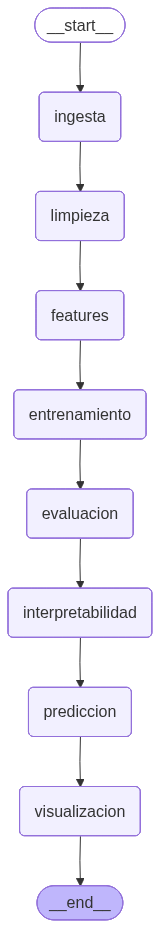

In [13]:
# ============================================================
# AGENTE 1 — COORDINADOR (LangGraph StateGraph)
# ============================================================
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

def build_nanotox_pipeline() -> StateGraph:
    """Construye el grafo del sistema multi-agente de nanotoxicidad."""
    workflow = StateGraph(NanoToxState)

    # ── Registrar los 8 agentes especializados como nodos ──
    workflow.add_node("ingesta",           agent_ingest)
    workflow.add_node("limpieza",          agent_clean)
    workflow.add_node("features",          agent_features)
    workflow.add_node("entrenamiento",     agent_train)
    workflow.add_node("evaluacion",        agent_evaluate)
    workflow.add_node("interpretabilidad", agent_interpret)
    workflow.add_node("prediccion",        agent_predict)
    workflow.add_node("visualizacion",     agent_visualize)

    # ── Definir el flujo secuencial ──
    workflow.set_entry_point("ingesta")
    workflow.add_edge("ingesta",           "limpieza")
    workflow.add_edge("limpieza",          "features")
    workflow.add_edge("features",          "entrenamiento")
    workflow.add_edge("entrenamiento",     "evaluacion")
    workflow.add_edge("evaluacion",        "interpretabilidad")
    workflow.add_edge("interpretabilidad", "prediccion")
    workflow.add_edge("prediccion",        "visualizacion")
    workflow.add_edge("visualizacion",     END)

    return workflow

# Compilar el grafo con checkpointing (memoria sensorial)
workflow = build_nanotox_pipeline()
memory   = MemorySaver()
app      = workflow.compile(checkpointer=memory)

print("✓ Grafo LangGraph compilado.")
print("  Flujo: ingesta → limpieza → features → entrenamiento → evaluacion → interpretabilidad → prediccion → visualizacion → END")

# Visualizar el grafo (si está disponible)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("\n  Diagrama Mermaid del grafo:")
    print(app.get_graph().draw_mermaid())

## Sección 14 — Demo End-to-End

Ejecuta el pipeline completo con una consulta de **ZnO nanoparticle cytotoxicity**.

> **Tiempo estimado:** 2-5 minutos (incluye descarga del dataset si no está localmente)

In [14]:
# ============================================================
# EJECUTAR PIPELINE COMPLETO
# ============================================================
import time

QUERY = "ZnO nanoparticle cytotoxicity"  # ← Cambia aquí si quieres otra NP

print("=" * 60)
print("  SISTEMA MULTI-AGENTE DE NANOTOXICIDAD")
print("  Predicción de Toxicidad de Nanopartículas con ML")
print("=" * 60)
print(f"  Consulta: '{QUERY}'")
print(f"  LangSmith: {'ACTIVO' if os.environ.get('LANGCHAIN_TRACING_V2') else 'inactivo'}")
print(f"  Neo4j: {'ACTIVO' if neo4j_available else 'fallback RAM'}")
print("=" * 60 + "\n")

# Estado inicial
state = initial_state(query=QUERY)
config = {"configurable": {"thread_id": "nanotox_demo_v1"}}

t0 = time.time()

# Ejecutar el grafo
final_state = app.invoke(state, config)

elapsed = time.time() - t0
print(f"\n{'=' * 60}")
print(f"  PIPELINE COMPLETADO en {elapsed:.1f} segundos")
print(f"  Estado final: {final_state.get('status', 'desconocido')}")
print(f"  Mejor modelo: {final_state.get('best_model_name', 'N/A')}")
best_scores = final_state.get('model_scores', {}).get(final_state.get('best_model_name', ''), {})
print(f"  Accuracy: {best_scores.get('accuracy', 0):.3f} | F1: {best_scores.get('f1', 0):.3f} | AUC: {best_scores.get('auc', 0):.3f}")
pred = final_state.get('prediction_result', {})
print(f"  Predicción: {pred.get('nanoparticle', 'N/A')} → Riesgo {pred.get('risk_level', 'N/A')} (prob={pred.get('probability', 0):.3f})")
print(f"  Figuras generadas: {len(final_state.get('viz_paths', []))}")
print("=" * 60)

  SISTEMA MULTI-AGENTE DE NANOTOXICIDAD
  Predicción de Toxicidad de Nanopartículas con ML
  Consulta: 'ZnO nanoparticle cytotoxicity'
  LangSmith: ACTIVO
  Neo4j: fallback RAM

[Agente 2] Iniciando ingesta de datos...
  ✓ Dataset cargado localmente: data\raw\zenodo_nanotoxicity\HaHa-Manual.csv
  Forma: 3440 filas × 17 columnas
  Columnas: ['material_type', 'core_size', 'hydro_size', 'surface_charge', 'surface_area', 'formation_enthalpy', 'conduction_band', 'valence_band']...

[Agente 2] ✓ Ingesta completada — 500 registros
[Agente 3] Iniciando limpieza de datos...
  Duplicados eliminados: 0 | Nulos imputados: 0 → 0 | Outliers extremos removidos: 334 | Forma final: 273 filas × 17 columnas (original: (500, 17))

[Agente 3] ✓ Limpieza completada
[Agente 4] Iniciando ingeniería de features...
  ✓ Target detectado: 'toxicity'
  Distribución target: {0: np.int64(273)} (0=no_tóxico, 1=tóxico)


c:\Users\natal\miniconda3\envs\ia_nano\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:106: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)


  ✓ Features seleccionadas (10): ['valence_band', 'electronegativity', 'exposure_time', 'exposure_dose', 'material_type_enc', 'assay_enc', 'cell_name_enc', 'cell_species_enc', 'cell_origin_enc', 'cell_type_enc']
  Train: (218, 10) | Test: (55, 10)

[Agente 4] ✓ Features preparadas
[Agente 5] Iniciando entrenamiento ML...
  Entrenando RandomForest... ✓ CV F1=nan ± nan
  Entrenando SVM... ✗ Error: The number of classes has to be greater than one; got 1 class
  Entrenando MLP... ✓ CV F1=nan ± nan

[Agente 5] ✓ Modelos entrenados: ['RandomForest', 'MLP']
[Agente 6] Evaluando modelos...
  ✗ Error evaluando RandomForest: index 1 is out of bounds for axis 1 with size 1
  MLP            : Acc=1.000 | F1=0.000 | AUC=nan

  ★ Mejor modelo: MLP (F1=0.000)

[Agente 6] ✓ Evaluación completada
[Agente 7] Calculando interpretabilidad...
  → SHAP no disponible ('_ArtistPropertiesSubstitution' object has no attribute 'update'). Usando feature_importances_.
  → Sin método de importancia disponible. Usan

c:\Users\natal\miniconda3\envs\ia_nano\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


  ⚠ LLM fallback: Error code: 404 - {'error': {'message': 'This model is unavailable for free. The paid version is available now - use this slug instead: google/gemma-3-12b-it', 'code': 404}, 'user_id': 'user_3ArUXspwR5YkNqMYnwhk9o0WAZm'}

[Agente 7] ✓ Interpretabilidad completada
[Agente 8] Generando predicción...
  Nanopartícula: ZnO nanoparticle cytotoxicity
  Predicción: NO TÓXICO (prob=1.000)
  Nivel de riesgo: ALTO

[Agente 8] ✓ Predicción completada
[Agente 9] Generando visualizaciones y reporte...
  [Aviso] matplotlib no disponible (AttributeError): '_ArtistPropertiesSubstitution' object has no attribute 'update'. Usando fallback PIL para generar imágenes.
  ✓ Figura 1 guardada: figuras\comparativa_modelos_fallback.png
  ✓ Figura 2 guardada: figuras\feature_importance_fallback.png
  ✓ Figura 3 guardada: figuras\roc_curve_fallback.png
  ⚠ LLM fallback: Error code: 404 - {'error': {'message': 'This model is unavailable for free. The paid version is available now - use this slug i

In [15]:
# ============================================================
# MOSTRAR REPORTE FINAL
# ============================================================
from IPython.display import Markdown, display

print("\n📊 REPORTE FINAL:\n")
print("-" * 60)
display(Markdown(final_state.get("report_md", "Reporte no generado.")))
print("-" * 60)

print("\n🔬 INTERPRETACIÓN DEL MODELO:")
print(final_state.get("interpretation_text", ""))

print("\n📈 COMPARATIVA DE MODELOS:")
import json
print(json.dumps(final_state.get("model_scores", {}), indent=2))

print("\n🧠 MEMORIA Neo4j — Nodos creados:")
if neo4j_available and neo4j_driver:
    with neo4j_driver.session() as session:
        result = session.run("MATCH (n) RETURN labels(n) as label, count(n) as count")
        for record in result:
            print(f"  {record['label']}: {record['count']} nodos")
else:
    print(f"  Nodos en RAM: {len(GRAPH_MEMORY)}")
    for nid, ndata in GRAPH_MEMORY.items():
        print(f"  [{ndata['type']}] {nid}: {list(ndata['properties'].keys())}")

print("\n✅ Sistema Multi-Agente ejecutado exitosamente.")


📊 REPORTE FINAL:

------------------------------------------------------------


# Reporte: Predicción de Toxicidad de Nanopartículas

## Resumen Ejecutivo
Se implementó un sistema multi-agente para predecir la toxicidad de nanopartículas.
El mejor modelo fue **MLP** con F1=0.000 y AUC=nan.

## Resultados
- **Accuracy:** 1.000
- **F1-Score:** 0.000
- **ROC-AUC:** nan

## Predicción
- Nanopartícula: ZnO nanoparticle cytotoxicity
- Nivel de riesgo: **ALTO**
- Probabilidad de toxicidad: 1.000

## Conclusiones
El modelo MLP identificó las siguientes propiedades como más predictivas de toxicidad: valence_band (0.1000), electronegativity (0.1000), exposure_time (0.1000), exposure_dose (0.1000), material_type_enc (0.1000). Propiedades como el tamaño, carga superficial y composición química son determinantes clave en la interacción de nanopartículas con sistemas biológicos.  


------------------------------------------------------------

🔬 INTERPRETACIÓN DEL MODELO:
El modelo MLP identificó las siguientes propiedades como más predictivas de toxicidad: valence_band (0.1000), electronegativity (0.1000), exposure_time (0.1000), exposure_dose (0.1000), material_type_enc (0.1000). Propiedades como el tamaño, carga superficial y composición química son determinantes clave en la interacción de nanopartículas con sistemas biológicos.

📈 COMPARATIVA DE MODELOS:
{
  "MLP": {
    "accuracy": 1.0,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "auc": NaN
  }
}

🧠 MEMORIA Neo4j — Nodos creados:
  Nodos en RAM: 3
  [Dataset] 7bd402e7: ['name', 'rows', 'cols', 'query', 'mp_band_gap']
  [MLModel] c4db7aed: ['name', 'f1', 'accuracy', 'auc']
  [Prediction] 3185af4a: ['nanoparticle', 'toxic', 'probability', 'risk_level']

✅ Sistema Multi-Agente ejecutado exitosamente.
